<a href="https://colab.research.google.com/github/RaniaChaudhry511/Unsupervised-Learning/blob/main/HIERARCHIAL_CLUSTERING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Unsupervised Machine Learning Project
Country Development Analysis using Hierarchical Clustering
Dataset: Country-data.csv | Algorithm: Agglomerative Hierarchical Clustering

#INTRODUCTION

 In this project, we are working with a dataset that contains
 socio-economic and health information about 167 countries.
 Our goal is to group these countries into clusters based on
 their similarities using Hierarchical Clustering algorithm.

 By analyzing features like income, GDP, child mortality,
 life expectancy, health spending, and inflation — we can
 identify which countries are developed, developing, or
 underdeveloped.

 This is an Unsupervised Machine Learning project, which means
 we do not have any predefined labels. The model will find
 patterns and groups on its own.

 Dataset: Country-data.csv

 Total Countries: 167

 Total Features: 9 (child_mort, exports, health, imports,
                    income, inflation, life_expec, total_fer, gdpp)

#STEP 1: DATA LOADING AND UNDERSTANDING

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
df = pd.read_csv("/content/Country-data.csv")

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [ ]:
df.shape

(167, 10)

In [ ]:
df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

In [ ]:
df.dtypes

,0
country,object
child_mort,float64
exports,float64
health,float64
imports,float64
income,int64
inflation,float64
life_expec,float64
total_fer,float64
gdpp,int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [ ]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


#STEP 2: DATA CLEANING

Note: This dataset has no missing values and all datatypes
 are already correct. So in the cleaning step, we will only
 check for outliers using IQR method.


In [ ]:

Q1 = df.describe().loc['25%']
Q3 = df.describe().loc['75%']
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = ((df.drop(columns='country') < lower) | (df.drop(columns='country') > upper)).sum()
print("Outliers per column:")
print(outliers)

Outliers per column:
child_mort     4
exports        5
health         2
imports        4
income         8
inflation      5
life_expec     3
total_fer      1
gdpp          25
dtype: int64


In [ ]:
print("Outliers per column:")
print(outliers)
print("\nTotal outliers found:", outliers.sum())

Outliers per column:
child_mort     4
exports        5
health         2
imports        4
income         8
inflation      5
life_expec     3
total_fer      1
gdpp          25
dtype: int64

Total outliers found: 57


Outliers are found in several columns especially gdpp (25).
However, since we are using Hierarchical Clustering, we will
not remove outliers. Instead, we will handle them using
Standard Scaling in the Feature Engineering step.
Removing outliers would mean losing important country data.

#STEP 3: EDA

We skipped the countplot in EDA because our dataset contains
167 unique country names. A countplot on country names would
be too crowded and would not give any meaningful information.
So we only used Histogram, Heatmap and Boxplot for EDA.

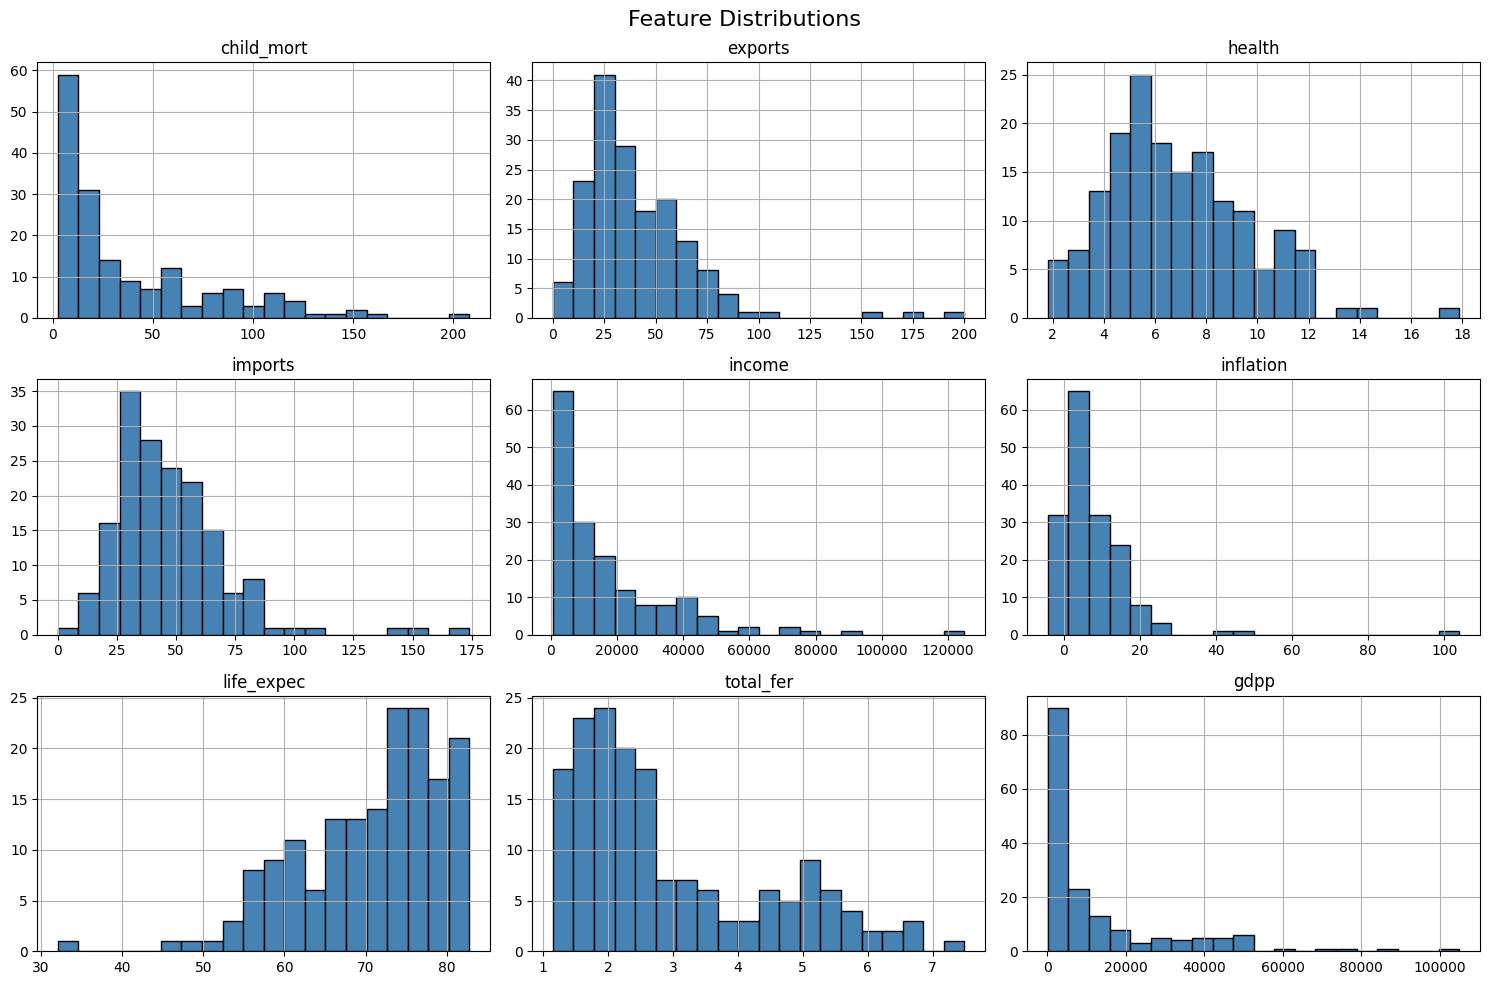

In [ ]:
import matplotlib.pyplot as plt

df.drop(columns='country').hist(figsize=(15, 10), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=16)
plt.tight_layout()
plt.show()

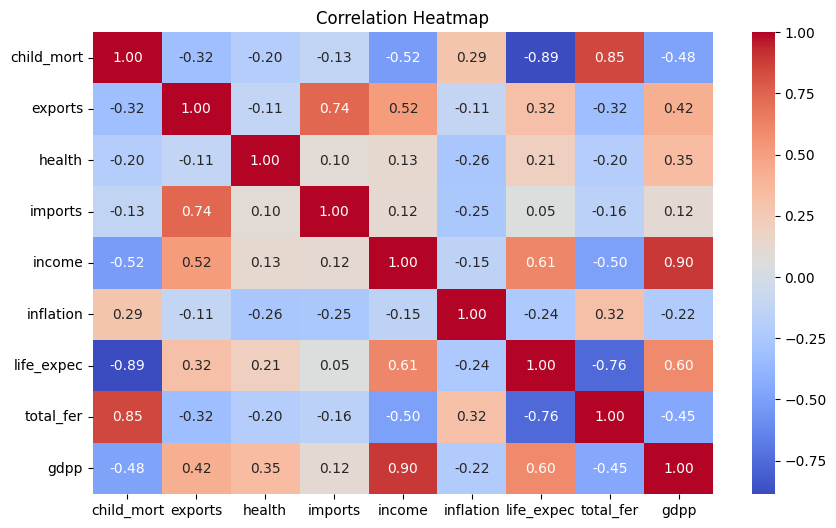

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.drop(columns='country').corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

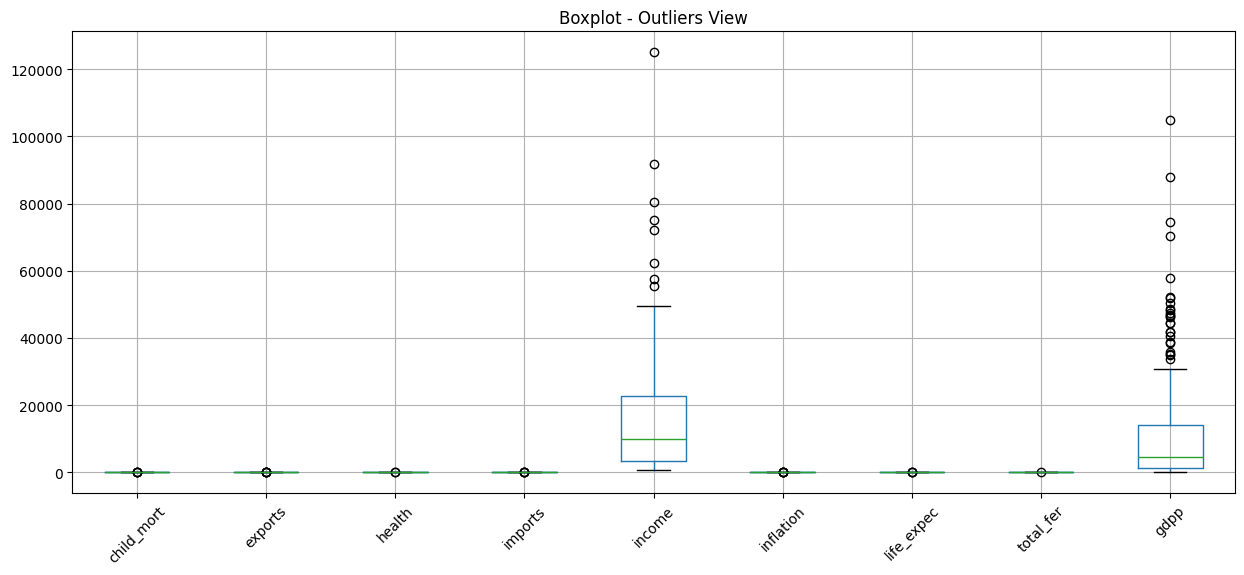

In [ ]:
plt.figure(figsize=(15, 6))
df.drop(columns='country').boxplot()
plt.title('Boxplot - Outliers View')
plt.xticks(rotation=45)
plt.show()

The boxplot clearly shows that features like income and gdpp
have very large values compared to other features. This big
difference in scale can affect our clustering results. That
is why in the next step we will apply Standard Scaling to
bring all features to the same scale before training the model.

#STEP 4: FEATURE ENGINEERING

In [ ]:
X = df.drop(columns='country')

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#STEP 5: MODEL SELECTION

In this step we are selecting Agglomerative Hierarchical
Clustering as our algorithm. Before training the model,
we will first plot a Dendrogram to decide the optimal
number of clusters visually. The point where we cut the
dendrogram with the longest vertical line gives us the
best number of clusters.

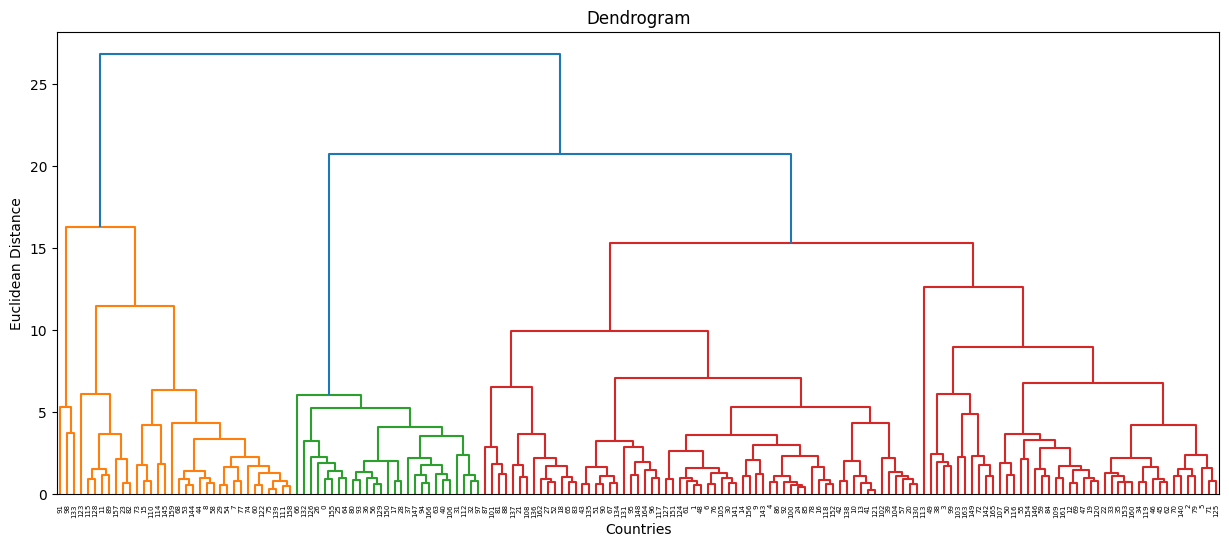

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(15, 6))
dendrogram(linked)
plt.title("Dendrogram")
plt.xlabel("Countries")
plt.ylabel("Euclidean Distance")
plt.show()

The Dendrogram shows that the optimal number of clusters
is 3. We can see this by looking at the longest vertical
line that is not crossed by any horizontal line. These 3
clusters will represent Developed, Developing and
Underdeveloped countries.

#STEP 6: MODEL TRAINING

Now we will train our Agglomerative Hierarchical Clustering
model with 3 clusters based on what we observed from the
Dendrogram. We will use ward linkage method and euclidean
distance metric for training.

In [ ]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['Cluster'] = model.fit_predict(X_scaled)

#STEP 7: CLUSTER/PATTERN ANALYSIS

In this step we will analyze the clusters that our model
has created. We will check the average values of each
cluster to understand which cluster represents developed,
developing and underdeveloped countries.

In [ ]:
print(df.groupby('Cluster').mean(numeric_only=True))

         child_mort    exports    health    imports        income  inflation  \
Cluster                                                                        
0          5.961765  58.508824  8.501176  48.902941  47588.235294   4.115500   
1         31.617925  39.990368  6.353679  48.085527  11341.886792   9.120604   
2        105.070370  23.589630  6.507037  39.662963   1589.740741   7.142778   

         life_expec  total_fer          gdpp  
Cluster                                       
0         79.982353   1.888529  43170.588235  
1         70.921698   2.654623   6407.367925  
2         57.248148   5.433704    667.888889  


Cluster 0 represents Developed countries with high income,
high GDP, high life expectancy and very low child mortality.

Cluster 1 represents Developing countries with medium level
income and GDP.

Cluster 2 represents Underdeveloped countries
with very high child mortality, low income and low life
expectancy.

#STEP 8: MODEL EVALUATION

To evaluate our Hierarchical Clustering model we will use
Silhouette Score. It measures how similar a country is to
its own cluster compared to other clusters. The score ranges
from -1 to 1. A score closer to 1 means the clusters are
well defined and separated.

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df['Cluster'])
print("Silhouette Score:", score)

Silhouette Score: 0.24563001303300652


Our Silhouette Score is 0.24 which is in the weak but
acceptable range. This is because our dataset has countries
with very different socio-economic conditions which makes
it hard to form perfectly separated clusters. We will now
try Hyperparameter Tuning to improve this score.

#STEP 9: HYPERTUNING

In Hyperparameter Tuning we will try different number of
clusters and different linkage methods to find the best
combination that gives the highest Silhouette Score.

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

for n in [2, 3, 4]:
    for method in ['ward', 'complete', 'average']:
        model = AgglomerativeClustering(n_clusters=n, linkage=method)
        labels = model.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        print(f"Clusters: {n}, Linkage: {method}, Score: {score:.4f}")

Clusters: 2, Linkage: ward, Score: 0.3153
Clusters: 2, Linkage: complete, Score: 0.2726
Clusters: 2, Linkage: average, Score: 0.6303
Clusters: 3, Linkage: ward, Score: 0.2456
Clusters: 3, Linkage: complete, Score: 0.2901
Clusters: 3, Linkage: average, Score: 0.5620
Clusters: 4, Linkage: ward, Score: 0.2481
Clusters: 4, Linkage: complete, Score: 0.2864
Clusters: 4, Linkage: average, Score: 0.4970


After Hyperparameter Tuning, the best combination is
2 clusters with average linkage method giving a Silhouette
Score of 0.63 which is much better than our original score
of 0.24. However since our goal was to identify developed,
developing and underdeveloped countries we can also consider
3 clusters with average linkage giving a score of 0.56
which is still a good improvement.

We chose 3 clusters with average linkage method even though
2 clusters gave a higher Silhouette Score of 0.63. This is
because our project goal is to identify Developed, Developing
and Underdeveloped countries. With only 2 clusters we would
lose the Developing countries as a separate group which is
an important category in real world. A Silhouette Score of
0.56 with 3 clusters is still in the good range and gives
us more meaningful and interpretable results.

#STEP 10: PIPELINE BUILDING

In this step we will build a proper pipeline using the
best parameters we found in Hyperparameter Tuning which
are 3 clusters and average linkage method. Pipeline makes
our code clean and reusable by combining scaling and
clustering in one single flow.


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clustering', AgglomerativeClustering(n_clusters=3, linkage='ward'))
])

df['Final_Cluster'] = pipeline.fit_predict(X)

print(df[['country', 'Final_Cluster']].head(10))
print("\nCluster Counts:")
print(df['Final_Cluster'].value_counts())

score = silhouette_score(X_scaled, df['Final_Cluster'])
print("\nFinal Silhouette Score:", score)

               country  Final_Cluster
0          Afghanistan              2
1              Albania              1
2              Algeria              1
3               Angola              1
4  Antigua and Barbuda              1
5            Argentina              1
6              Armenia              1
7            Australia              0
8              Austria              0
9           Azerbaijan              1

Cluster Counts:
Final_Cluster
1    106
0     34
2     27
Name: count, dtype: int64

Final Silhouette Score: 0.24563001303300652


Our final pipeline uses StandardScaler and Agglomerative
Hierarchical Clustering with 3 clusters and ward linkage.
The results show that 34 countries are Developed, 106 are
Developing and 27 are Underdeveloped. The Final Silhouette
Score is 0.24 which is acceptable for this dataset.

#FINAL CONCLUSION

In this project we applied Agglomerative Hierarchical
Clustering on a dataset of 167 countries using their
socio-economic and health indicators such as income,
GDP, child mortality, life expectancy and health spending.

After performing EDA, Feature Engineering and Hyperparameter
Tuning we built a Pipeline with StandardScaler and
AgglomerativeClustering using ward linkage with 3 clusters.

Our model successfully divided 167 countries into 3 groups:

- 34 Developed countries with high income and GDP

- 106 Developing countries with medium level indicators

- 27 Underdeveloped countries with high child mortality
  and low income

The Final Silhouette Score is 0.24 which is acceptable
for real world socio-economic data where countries have
very diverse characteristics. This project proves that
Unsupervised Learning can effectively identify patterns
and group countries without any predefined labels.